In [1]:
import kagglehub
path = kagglehub.dataset_download("uciml/student-alcohol-consumption")

100%|██████████| 18.4k/18.4k [00:00<00:00, 22.1MB/s]

Extracting files...


In [2]:
import os
import pandas as pd

# List the contents of the downloaded directory
print(os.listdir(path))

['student-por.csv', 'student-mat.csv', 'student-merge.R']


It looks like there are two CSV files: `student-mat.csv` and `student-por.csv`. These likely represent students studying mathematics and Portuguese, respectively. Let's load both of them into pandas DataFrames and inspect their heads.

In [6]:
student_mat_df = pd.read_csv(os.path.join(path, 'student-mat.csv'))
student_por_df = pd.read_csv(os.path.join(path, 'student-por.csv'))

# Add a 'subject' column to each dataframe
student_mat_df['subject'] = 'math'
student_por_df['subject'] = 'portuguese'

# Concatenate the two dataframes
student_df = pd.concat([student_mat_df, student_por_df], ignore_index=True)

print("\n--- Combined Student Data (Head) ---")
display(student_df.head())

print(f"\nShape of combined dataframe: {student_df.shape}")


--- Combined Student Data (Head) ---


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,math



Shape of combined dataframe: (1044, 34)


Now that we have successfully concatenated the two datasets, let's look at the general information and descriptive statistics for the `student_df`. This will help us identify any missing values, understand the data types, and get a clearer picture of the distribution of numerical and categorical features.

In [7]:
print("\n--- Combined Student Data Information (Concatenated) ---")
student_df.info()

print("\n--- Combined Student Data Descriptive Statistics (Concatenated) ---")
display(student_df.describe(include='all'))


--- Combined Student Data Information (Concatenated) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   ob

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
count,1044,1044,1044.000000,1044,1044,1044,1044.000000,1044.000000,1044,1044,...,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,portuguese
freq,772,591,NaN,759,738,923,NaN,NaN,399,584,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,649
mean,NaN,NaN,16.726054,NaN,NaN,NaN,2.603448,2.387931,NaN,NaN,...,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954,NaN
std,NaN,NaN,1.239975,NaN,NaN,NaN,1.124907,1.099938,NaN,NaN,...,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796,NaN
min,NaN,NaN,15.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,16.000000,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,...,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000,NaN
50%,NaN,NaN,17.000000,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN,...,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000,NaN
75%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,...,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000,NaN


From the `info()` and `describe()` outputs, we can observe that there are several categorical features (dtype `object`) and numerical features (dtype `int64`). Many of the 'numerical' features like `Medu`, `Fedu`, `traveltime`, `studytime`, `failures`, `famrel`, `freetime`, `goout`, `Dalc`, `Walc`, `health`, and `absences` are ordinal or count-based. For deep learning, it's generally best to one-hot encode truly nominal categorical variables and scale numerical/ordinal variables. Let's start by separating these.

In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical and numerical columns
categorical_cols = student_df.select_dtypes(include='object').columns
numerical_cols = student_df.select_dtypes(include=['int64', 'float64']).columns.drop(['G1', 'G2', 'G3'])

print(f"Categorical columns: {list(categorical_cols)}")
print(f"Numerical columns: {list(numerical_cols)}")

# Define preprocessing steps
# One-hot encode categorical features
# Scale numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Separate features (X) and target (y)
X = student_df.drop(columns=['G1', 'G2', 'G3'])
y = student_df['G3']

print("\nFeatures (X) before preprocessing (head):")
display(X.head())
print("Target (y) before preprocessing (head):")
display(y.head())


Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'subject']
Numerical columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Features (X) before preprocessing (head):


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,math
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,math
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,math


Target (y) before preprocessing (head):


,G3
0,6
1,6
2,10
3,15
4,10


Now that we have defined our preprocessing steps and separated features from the target variable, let's apply the preprocessing to our features. This will transform categorical variables into a numerical format suitable for machine learning models and scale the numerical features. After preprocessing, we'll display the shape of the transformed features to confirm the changes.

In [9]:
# Apply preprocessing to X
X_processed = preprocessor.fit_transform(X)

print(f"Shape of preprocessed features (X_processed): {X_processed.shape}")

Shape of preprocessed features (X_processed): (1044, 58)


With the features preprocessed, the next crucial step is to split our data into training and testing sets. This allows us to train the deep learning model on one portion of the data and evaluate its performance on unseen data, ensuring that the model generalizes well. We will use `train_test_split` from `sklearn.model_selection` for an 80/20 split.

In [10]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (835, 58)
Shape of X_test: (209, 58)
Shape of y_train: (835,)
Shape of y_test: (209,)


With our data prepared, we can now define and compile our deep learning model. Since we are predicting a final grade (a numerical value), this is a regression task. We'll use a simple sequential model with Dense layers, which are standard fully connected layers. I'll use `ReLU` activation for hidden layers and a linear activation for the output layer, which is typical for regression. The mean squared error (`mse`) will be used as the loss function, and `Adam` as the optimizer.

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)), # Input layer with 128 neurons
    Dense(64, activation='relu'),  # Hidden layer with 64 neurons
    Dense(32, activation='relu'),  # Hidden layer with 32 neurons
    Dense(1)  # Output layer for regression (single numerical output)
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])

print("\n--- Model Summary ---")
model.summary()


--- Model Summary ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         7,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,921 (70.00 KB)

 Trainable params: 17,921 (70.00 KB)

 Non-trainable params: 0 (0.00 B)

Now, let's train our deep learning model. We'll use the `fit` method with our training data (`X_train`, `y_train`) and specify a validation split to monitor performance during training. We'll also add `EarlyStopping` to stop training if the validation loss doesn't improve after a certain number of epochs, and `ModelCheckpoint` to save the best model weights.

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2, # Use a portion of the training data for validation
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

print("\n--- Model Training History ---")
# Display some training metrics
hist_df = pd.DataFrame(history.history)
display(hist_df.head())

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 6.7026 - mae: 1.8544 - mse: 6.7026 - val_loss: 10.5056 - val_mae: 2.4391 - val_mse: 10.5056
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.2761 - mae: 1.8248 - mse: 6.2761 - val_loss: 10.1868 - val_mae: 2.3942 - val_mse: 10.1868
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.9460 - mae: 1.7770 - mse: 5.9460 - val_loss: 10.5292 - val_mae: 2.4597 - val_mse: 10.5292
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.5633 - mae: 1.7318 - mse: 5.5633 - val_loss: 10.3956 - val_mae: 2.4527 - val_mse: 10.3956
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 5.2119 - mae: 1.6673 - mse: 5.2119 - val_loss: 10.6888 - val_mae: 2.4197 - val_mse: 10.6888
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.9646 - mae: 1.6345 - mse: 4.9646 - val_loss: 10.5434 - val_mae: 2.4113 - val_mse: 10.5434
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.6536 - mae: 1.6057 - mse: 4.

,loss,mae,mse,val_loss,val_mae,val_mse
0,6.702608,1.854386,6.702608,10.505647,2.439116,10.505647
1,6.276143,1.824801,6.276143,10.186771,2.394219,10.186771
2,5.945954,1.776951,5.945954,10.529241,2.459707,10.529241
3,5.563254,1.731762,5.563254,10.395636,2.452739,10.395636
4,5.211852,1.667326,5.211852,10.688832,2.419661,10.688832


After training, it's essential to evaluate the model's performance on the test set, which it has not seen before. This will give us an unbiased estimate of how well our model generalizes to new, unseen data. We'll also visualize the training history to understand the learning curve.


--- Model Evaluation on Test Set ---
Test Loss (MSE): 13.3392
Test MAE: 2.6292


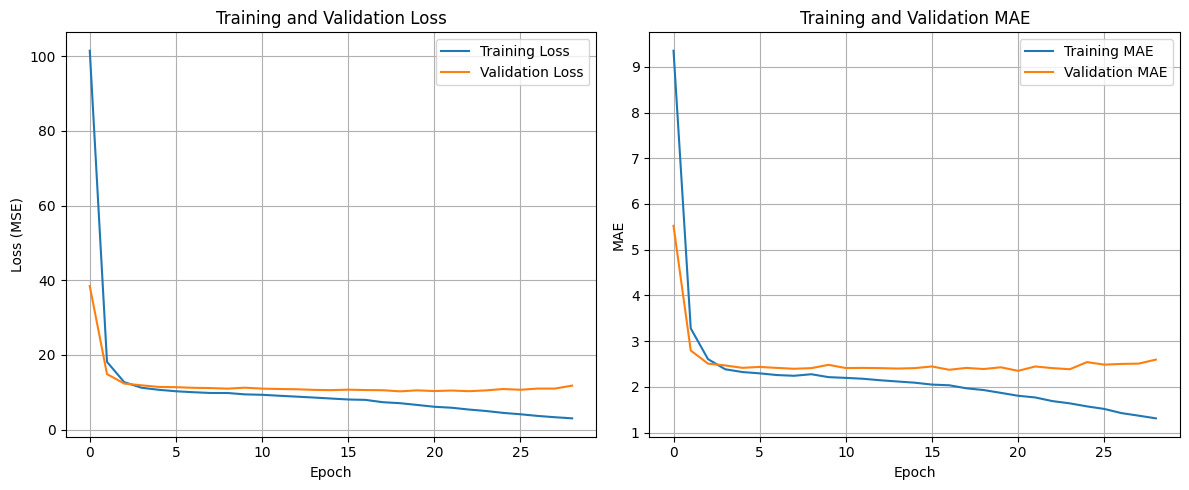

In [13]:
# Evaluate the model on the test set
loss, mae, mse = model.evaluate(X_test, y_test, verbose=0)

print(f"\n--- Model Evaluation on Test Set ---")
print(f"Test Loss (MSE): {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

# Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

The evaluation results and the plots of training history provide insights into the model's performance. Now, let's make some predictions on the test set and compare them with the actual grades. This will give us a practical understanding of how accurate our model's predictions are.

In [14]:
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test).flatten()

# Create a DataFrame for comparison
predictions_df = pd.DataFrame({'Actual G3': y_test, 'Predicted G3': y_pred.round(0)})

print("\n--- Sample of Actual vs. Predicted G3 Scores ---")
display(predictions_df.head(10))

# Calculate some common regression metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_test = mean_absolute_error(y_test, y_pred)
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred)

print(f"\nMean Absolute Error (Test): {mae_test:.4f}")
print(f"Mean Squared Error (Test): {mse_test:.4f}")
print(f"Root Mean Squared Error (Test): {rmse_test:.4f}")
print(f"R-squared (Test): {r2_test:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

--- Sample of Actual vs. Predicted G3 Scores ---


,Actual G3,Predicted G3
971,11,13.0
280,8,10.0
536,13,13.0
824,11,12.0
644,12,11.0
777,11,13.0
978,0,7.0
231,11,11.0
660,15,12.0
548,13,14.0



Mean Absolute Error (Test): 2.6292
Mean Squared Error (Test): 13.3392
Root Mean Squared Error (Test): 3.6523
R-squared (Test): 0.1372


Before creating the Streamlit application, we need to save the `preprocessor` object. This `ColumnTransformer` is crucial for applying the same scaling and one-hot encoding to new input data as was applied during model training. We'll use `joblib` for this purpose.

In [15]:
import joblib

# Save the preprocessor
joblib.dump(preprocessor, 'preprocessor.joblib')

print("Preprocessor saved to 'preprocessor.joblib'")

Preprocessor saved to 'preprocessor.joblib'


Now, let's create the Streamlit application file (`app.py`). This script will:

1.  Load the trained Keras model (`best_model.h5`).
2.  Load the saved preprocessor (`preprocessor.joblib`).
3.  Define input widgets for all features.
4.  Process the input using the loaded preprocessor.
5.  Make a prediction using the model.
6.  Display the predicted `G3` score.

To run this app, you'll need to install Streamlit (`pip install streamlit`) and then execute `streamlit run app.py` in your terminal. Note: You might need to download `app.py` and `best_model.h5` and `preprocessor.joblib` to your local machine if running outside of Colab.

In [39]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import tensorflow as tf
import joblib

# Load the trained model (now in .keras format) with safe_mode=False
model = tf.keras.models.load_model('best_model.keras', safe_mode=False)

# Load the preprocessor
preprocessor = joblib.load('preprocessor.joblib')

# Get the list of numerical and categorical columns from the original setup
categorical_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'subject']
numerical_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

unique_values = {
    'school': ['GP', 'MS'],
    'sex': ['F', 'M'],
    'address': ['U', 'R'],
    'famsize': ['GT3', 'LE3'],
    'Pstatus': ['A', 'T'],
    'Mjob': ['at_home', 'health', 'other', 'services', 'teacher'],
    'Fjob': ['at_home', 'health', 'other', 'services', 'teacher'],
    'reason': ['course', 'home', 'other', 'reputation'],
    'guardian': ['father', 'mother', 'other'],
    'schoolsup': ['yes', 'no'],
    'famsup': ['yes', 'no'],
    'paid': ['yes', 'no'],
    'activities': ['yes', 'no'],
    'nursery': ['yes', 'no'],
    'higher': ['yes', 'no'],
    'internet': ['yes', 'no'],
    'romantic': ['yes', 'no'],
    'subject': ['math', 'portuguese']
}

# Streamlit app layout
st.title("🎓 Student Grade (G3) Prediction")
st.write("Enter student details in the sidebar to predict their final grade (G3).")

# --- Sidebar for inputs ---
with st.sidebar:
    st.title("📊 Student Details Input")

    # Create input widgets for each feature in the sidebar
    input_data = {}

    st.header("Personal Information")
    input_data['school'] = st.selectbox("Select School:", unique_values['school'])
    input_data['sex'] = st.selectbox("Select Sex:", unique_values['sex'])
    input_data['age'] = st.number_input("Enter Age:", min_value=15, max_value=22, value=17)
    input_data['address'] = st.selectbox("Select Address Type:", unique_values['address'])
    input_data['famsize'] = st.selectbox("Select Family Size:", unique_values['famsize'])
    input_data['Pstatus'] = st.selectbox("Select Parents' Cohabitation Status:", unique_values['Pstatus'])

    st.header("Parental & Home Background")
    input_data['Medu'] = st.slider("""Mother's Education (0-4):
0: none, 1: primary education, 2: 5th to 9th grade, 3: secondary education, 4: higher education""", min_value=0, max_value=4, value=2)
    input_data['Fedu'] = st.slider("""Father's Education (0-4):
0: none, 1: primary education, 2: 5th to 9th grade, 3: secondary education, 4: higher education""", min_value=0, max_value=4, value=2)
    input_data['Mjob'] = st.selectbox("Mother's Job:", unique_values['Mjob'])
    input_data['Fjob'] = st.selectbox("Father's Job:", unique_values['Fjob'])
    input_data['reason'] = st.selectbox("Reason to choose this school:", unique_values['reason'])
    input_data['guardian'] = st.selectbox("Guardian:", unique_values['guardian'])

    st.header("School & Study Habits")
    input_data['traveltime'] = st.slider("""Travel Time (1-4):
1: <15 min, 2: 15-30 min, 3: 30-60 min, 4: >60 min""", min_value=1, max_value=4, value=2)
    input_data['studytime'] = st.slider("""Study Time (1-4):
1: <2 hours, 2: 2 to 5 hours, 3: 5 to 10 hours, 4: >10 hours""", min_value=1, max_value=4, value=2)
    input_data['failures'] = st.number_input("Number of Past Class Failures:", min_value=0, max_value=4, value=0)
    input_data['schoolsup'] = st.selectbox("Extra Educational Support:", unique_values['schoolsup'])
    input_data['famsup'] = st.selectbox("Family Educational Support:", unique_values['famsup'])
    input_data['paid'] = st.selectbox("Extra Paid Classes:", unique_values['paid'])
    input_data['activities'] = st.selectbox("Extra-curricular Activities:", unique_values['activities'])
    input_data['nursery'] = st.selectbox("Attended Nursery School:", unique_values['nursery'])
    input_data['higher'] = st.selectbox("Intention to take Higher Education:", unique_values['higher'])
    input_data['internet'] = st.selectbox("Internet Access at Home:", unique_values['internet'])
    input_data['romantic'] = st.selectbox("In a Romantic Relationship:", unique_values['romantic'])
    input_data['subject'] = st.selectbox("Subject of Study:", unique_values['subject'])

    st.header("Social & Health Factors")
    input_data['famrel'] = st.slider("""Quality of Family Relationships (1-5):
1: very bad, 5: excellent""", min_value=1, max_value=5, value=3)
    input_data['freetime'] = st.slider("""Free Time After School (1-5):
1: very little, 5: very much""", min_value=1, max_value=5, value=3)
    input_data['goout'] = st.slider("""Going Out with Friends (1-5):
1: very little, 5: very much""", min_value=1, max_value=5, value=3)
    input_data['Dalc'] = st.slider("""Workday Alcohol Consumption (1-5):
1: very low, 5: very high""", min_value=1, max_value=5, value=1)
    input_data['Walc'] = st.slider("""Weekend Alcohol Consumption (1-5):
1: very low, 5: very high""", min_value=1, max_value=5, value=1)
    input_data['health'] = st.slider("""Current Health Status (1-5):
1: very bad, 5: very good""", min_value=1, max_value=5, value=3)
    input_data['absences'] = st.number_input("Number of School Absences:", min_value=0, max_value=75, value=0)

# Use columns to center the prediction button and result
col1, col2, col3 = st.columns([1, 2, 1]) # Adjust ratios as needed for centering

with col2:
    # Prediction button within the main panel, now centered
    if st.button('🚀 Predict G3'):
        # Convert input data to a DataFrame
        input_df = pd.DataFrame([input_data])

        # The original order of columns in X used for training was:
        original_X_cols = ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'subject']

        # Ensure the input_df has the same columns and order as X used for preprocessor.fit_transform
        input_df = input_df[original_X_cols]

        processed_input = preprocessor.transform(input_df)

        # Make prediction
        prediction = model.predict(processed_input)[0][0]

        # Display the prediction, now centered
        st.success(f"Predicted Final Grade (G3): {round(prediction):.0f} / 20")

st.write("\n--- Notes ---")
st.write("This app uses a deep learning model trained on the student alcohol consumption dataset.")
st.write("G3 is the final year grade, ranging from 0 to 20.")

Overwriting app.py


In [17]:
!pip install --ignore-installed blinker
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 95.7 MB/s eta 0:00:00


In [18]:
!pip install streamlit pyngrok

In [19]:
from pyngrok import ngrok
ngrok.set_auth_token("3H2nxZtP4iC5L9tX9K97OPLut9W_4JsZrRVF5aRFQpQCCePy1")

In [40]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://vanity-amperage-commodore.ngrok-free.dev" -> "http://localhost:8501"


In [41]:
# Run the Streamlit app
# This will provide a public URL to access the app
!streamlit run app.py &




2026-08-20 13:51:45.806 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.223.15.151:8501

2026-08-20 13:51:53.523097: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64m